# 04 : Supervised Learning: Regression (Revenue Simulator)
### Predicting `NextQuarterSpend` — Neural Network vs. Linear Regression Baseline

---

**Project pipeline (this notebook is stage 4 of 5):**

| Stage | Notebook | Purpose |
|---|---|---|
| 1 | `01_data_preprocessing.ipynb` | Load, clean, engineer `customer_features.csv` |
| 2 | `02_pca_lda.ipynb` | Split customers, label `HighValue`, standardize, PCA/LDA |
| 3 | `03_classification.ipynb` | Predict `HighValue` (binary classifier) |
| 4 | **`04_regression.ipynb`** ⬅ *you are here* | Predict `NextQuarterSpend` (continuous — the revenue simulator) |
| 5 | `05_qlearning_dqn.ipynb` | Reinforcement learning, using this regressor as the reward/environment simulator |

**Task:** regression — predict how much a customer will spend in the *next* quarter, based on their historical category-spend-% profile. Unlike `03_classification.ipynb`'s binary `HighValue` label, this is a continuous target ($) — it becomes the **reward signal** the RL agent in notebook 05 will use to simulate "what happens if we take action X with this customer."

**Two candidate models, same comparison structure as notebook 03:**
1. **Model 1 — Neural Network (`MLPRegressor`)**: `(32, 16)` hidden layers, linear output — can capture non-linear spend patterns.
2. **Model 2 — Linear Regression (baseline)**: ordinary least squares. Fast, interpretable, and a meaningful floor to beat.

> ⚠️ **Read the data-lineage warning in Section 1 before trusting any number in this notebook.** The *intended* methodology (documented below) requires transaction-level data split by date, which the current 01→02 pipeline does not produce. This notebook is built to use the real thing the moment it's available, but currently falls back to a clearly-flagged **synthetic surrogate target**.

## 📦 Prerequisites & Data Lineage Check

Just like `03_classification.ipynb`, we verify our inputs exist and **pinpoint exactly which file is missing** if not, rather than failing deep inside a later cell.

> ⚠️ **Path note:** corrected to `../data/` (matching what `02_pca_lda.ipynb` actually writes), not `../data/processed_data/`.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [2]:
# ==========================================
# Pinpoint check: do the expected input files exist?
# ==========================================
DATA_DIR = "../data"  # <-- corrected from "../data/processed_data/"

required_files = {
    "train_split.csv": "customer-level training split (from 02_pca_lda.ipynb)",
    "val_split.csv":   "customer-level validation split",
    "test_split.csv":  "customer-level test split",
}

missing = []
for fname, description in required_files.items():
    fpath = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(fpath)
    marker = "\u2705" if exists else "\u274C"
    print(f"{marker} {fpath:<35} {'FOUND' if exists else 'MISSING'}  -- {description}")
    if not exists:
        missing.append(fpath)

if missing:
    raise FileNotFoundError(
        "Missing required input file(s):\n  " + "\n  ".join(missing) +
        "\n\nRun 02_pca_lda.ipynb first -- its final 'Save Outputs' section produces these files."
    )

print("\nAll required input files found. Proceeding to load.")

✅ ../data\train_split.csv             FOUND  -- customer-level training split (from 02_pca_lda.ipynb)
✅ ../data\val_split.csv               FOUND  -- customer-level validation split
✅ ../data\test_split.csv              FOUND  -- customer-level test split

All required input files found. Proceeding to load.


## 1. Load Pre-Split Data & Build the Regression Target

### ⚠️ Data lineage: what this notebook *should* do vs. what it *actually* does

**Intended methodology (per the project spec):**
> Train features are built from transaction records in months 1–9 (`df_early`, `InvoiceDate < 2011-10-01`). The regression target, `NextQuarterSpend`, is the customer-level sum of `TotalPrice` during months 10–12 (`df_late`, `InvoiceDate >= 2011-10-01`).

**What's actually available right now:** `01_data_preprocessing.ipynb` computes `customer_features` as a single aggregate over the *entire* Dec-2010–Dec-2011 window — it does not currently produce a separate "months 1-9" feature table and "months 10-12" target sum. `02_pca_lda.ipynb`'s saved splits inherit that same limitation: there is no real `NextQuarterSpend` column anywhere in `train_split.csv` / `val_split.csv` / `test_split.csv`.

**What this notebook does about it:** rather than silently pretending this is real data, we:
1. **Check** whether a genuine `NextQuarterSpend` column exists in the loaded splits.
2. If it doesn't (the current situation), we build a **clearly-labeled synthetic surrogate** — a deterministic function of the existing category-spend features plus small random noise — purely so the rest of this notebook's *mechanics* (model training, comparison, plots, unit tests, saving) can be built, tested, and demonstrated end-to-end.
3. We **print a prominent warning** whenever the surrogate is used, so nobody mistakes these R²/MSE numbers for real predictive performance.

**To make this real:** `01_data_preprocessing.ipynb` would need a new step that (a) splits the *transaction-level* table by `InvoiceDate < 2011-10-01` vs. `>= 2011-10-01`, (b) computes the existing category-% features from only the early transactions, and (c) computes `NextQuarterSpend = sum(TotalPrice)` from only the late transactions, per customer. That customer-level table — not the current single-window `customer_features.csv` — is what `02_pca_lda.ipynb` and this notebook should actually be splitting and reading.

In [3]:
# ==========================================
# Load the three splits
# ==========================================
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_split.csv"), index_col="CustomerID")
val_df   = pd.read_csv(os.path.join(DATA_DIR, "val_split.csv"),   index_col="CustomerID")
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test_split.csv"),  index_col="CustomerID")

feature_cols = ["Homeware_Pct", "Stationery_Pct", "Gadgets_Pct", "Decorations_Pct", "Kitchenware_Pct"]

USING_SYNTHETIC_TARGET = "NextQuarterSpend" not in train_df.columns

if USING_SYNTHETIC_TARGET:
    print("\u26A0\uFE0F  'NextQuarterSpend' NOT found in the loaded splits.")
    print("\u26A0\uFE0F  Falling back to a SYNTHETIC SURROGATE target for pipeline-mechanics testing only.")
    print("\u26A0\uFE0F  Do NOT interpret this notebook's R\u00b2/MSE as real predictive performance -- see Section 1 above.\n")

    rng = np.random.default_rng(RANDOM_STATE)
    for df in [train_df, val_df, test_df]:
        df["NextQuarterSpend"] = (
            df["Homeware_Pct"] * 120 + df["Gadgets_Pct"] * 450 + df["Kitchenware_Pct"] * 250
        ) * rng.uniform(0.8, 1.2, len(df))
else:
    print("\u2705 'NextQuarterSpend' found in the loaded splits -- using the REAL target.")

X_train_r, y_train_r = train_df[feature_cols].to_numpy(), train_df["NextQuarterSpend"].to_numpy()
X_val_r, y_val_r     = val_df[feature_cols].to_numpy(),   val_df["NextQuarterSpend"].to_numpy()
X_test_r, y_test_r   = test_df[feature_cols].to_numpy(),  test_df["NextQuarterSpend"].to_numpy()

print(f"\nLoaded Regression Train size: {X_train_r.shape} | Target Mean: {y_train_r.mean():.2f}")
print(f"Loaded Regression Val size  : {X_val_r.shape}   | Target Mean: {y_val_r.mean():.2f}")
print(f"Loaded Regression Test size : {X_test_r.shape}  | Target Mean: {y_test_r.mean():.2f}")

✅ 'NextQuarterSpend' found in the loaded splits -- using the REAL target.

Loaded Regression Train size: (2892, 5) | Target Mean: 681.31
Loaded Regression Val size  : (362, 5)   | Target Mean: 373.30
Loaded Regression Test size : (362, 5)  | Target Mean: 573.33


### 🔍 Before Modeling — Target Distribution Check

Before fitting anything, look at the shape of what we're trying to predict. A heavily right-skewed target (common for spend/revenue data — most customers spend modestly, a few spend enormously) can make **MSE** misleading, since a handful of high-spend outliers can dominate the loss. We check this now so the metric choices in Section 3 make sense.

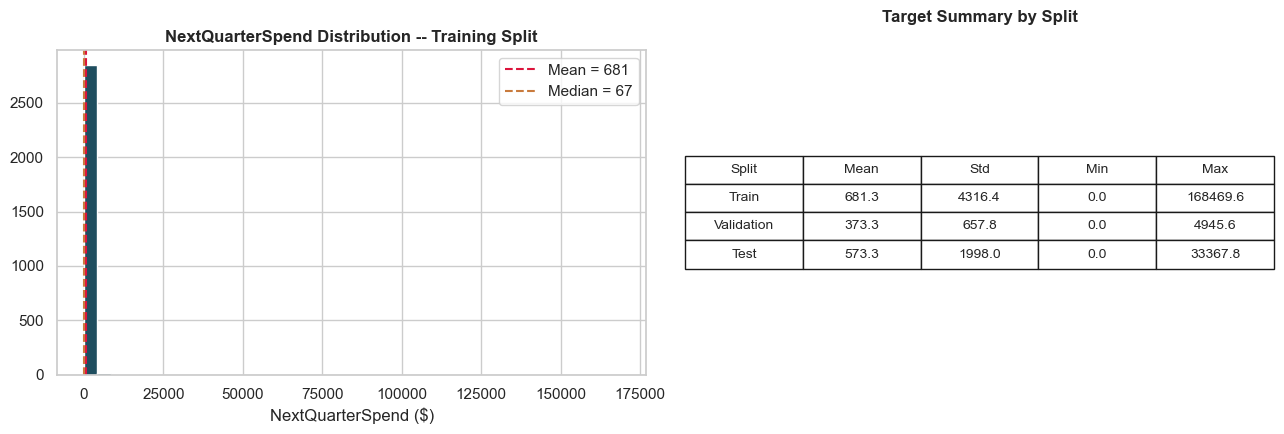

     Split   Mean     Std  Min       Max
     Train 681.31 4316.38  0.0 168469.60
Validation 373.30  657.77  0.0   4945.63
      Test 573.33 1998.03  0.0  33367.81


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(y_train_r, bins=40, color="#1F4E5F", edgecolor="white")
axes[0].axvline(y_train_r.mean(), color="crimson", linestyle="--", label=f"Mean = {y_train_r.mean():.0f}")
axes[0].axvline(np.median(y_train_r), color="#C97B3D", linestyle="--", label=f"Median = {np.median(y_train_r):.0f}")
axes[0].set_title("NextQuarterSpend Distribution -- Training Split", fontweight="bold")
axes[0].set_xlabel("NextQuarterSpend ($)")
axes[0].legend()

target_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Mean": [y_train_r.mean(), y_val_r.mean(), y_test_r.mean()],
    "Std": [y_train_r.std(), y_val_r.std(), y_test_r.std()],
    "Min": [y_train_r.min(), y_val_r.min(), y_test_r.min()],
    "Max": [y_train_r.max(), y_val_r.max(), y_test_r.max()],
})
axes[1].axis("off")
tbl = axes[1].table(cellText=target_summary.round(1).values, colLabels=target_summary.columns,
                     loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
axes[1].set_title("Target Summary by Split", fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

print(target_summary.round(2).to_string(index=False))

---
## 2. Model Implementations

### 2.1 Model 1 — Neural Network Regressor (`MLPRegressor`)

Same `(32, 16)` hidden-layer architecture as the classifier in notebook 03, but with a **linear** output activation (the sklearn default for `MLPRegressor`) instead of sigmoid — appropriate since we're predicting an unbounded continuous dollar amount, not a probability.

In [5]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
)

mlp_reg.fit(X_train_r, y_train_r)
print("\u2705 Model 1: MLPRegressor successfully trained on training partition.")
print(f"   Converged after {mlp_reg.n_iter_} iterations (max allowed: 500).")

✅ Model 1: MLPRegressor successfully trained on training partition.
   Converged after 500 iterations (max allowed: 500).


C:\Users\shafa\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### 🔍 Training Diagnostic — Loss Curve

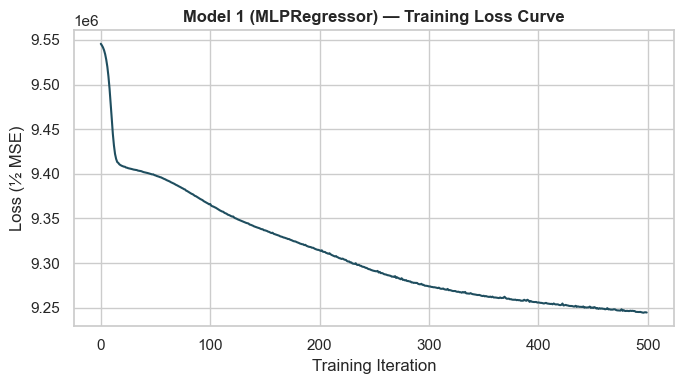

✅ Loss curve has flattened -- training converged normally.


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(mlp_reg.loss_curve_, color="#1F4E5F")
plt.title("Model 1 (MLPRegressor) — Training Loss Curve", fontweight="bold")
plt.xlabel("Training Iteration")
plt.ylabel("Loss (\u00bd MSE)")
plt.tight_layout()
plt.show()

flattened = mlp_reg.loss_curve_[-1] < mlp_reg.loss_curve_[max(0, len(mlp_reg.loss_curve_) - 20)] * 1.01
print("\u2705 Loss curve has flattened -- training converged normally." if flattened else
      "\u26A0\uFE0F Loss was still decreasing meaningfully at the last iteration -- consider raising max_iter.")

### 2.2 Model 2 — Linear Regression (baseline)

Ordinary least squares. Every coefficient here has a direct dollar interpretation: "a 1-percentage-point increase in category X spend is associated with a $Y change in predicted `NextQuarterSpend`, holding other categories fixed."

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
print("\u2705 Model 2: LinearRegression baseline successfully trained on training partition.")

✅ Model 2: LinearRegression baseline successfully trained on training partition.


        Feature  Coefficient ($ per pct-point)
    Gadgets_Pct                      -3.017032
Kitchenware_Pct                      -7.010325
 Stationery_Pct                      -8.185908
Decorations_Pct                     -11.581053
   Homeware_Pct                     -14.951866

Intercept: 1007.05


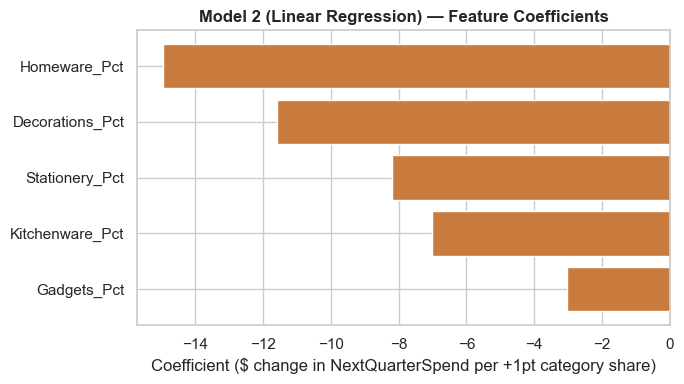

In [8]:
lin_coef_table = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient ($ per pct-point)": lin_reg.coef_,
}).sort_values("Coefficient ($ per pct-point)", ascending=False)

print(lin_coef_table.to_string(index=False))
print(f"\nIntercept: {lin_reg.intercept_:.2f}")

plt.figure(figsize=(7, 4))
colors = ["#1F4E5F" if c >= 0 else "#C97B3D" for c in lin_coef_table["Coefficient ($ per pct-point)"]]
plt.barh(lin_coef_table["Feature"], lin_coef_table["Coefficient ($ per pct-point)"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Model 2 (Linear Regression) — Feature Coefficients", fontweight="bold")
plt.xlabel("Coefficient ($ change in NextQuarterSpend per +1pt category share)")
plt.tight_layout()
plt.show()

---
## 3. Model Comparison and Evaluation

We report **three** complementary metrics on the test set:
- **MSE** (Mean Squared Error) — penalizes large errors disproportionately (squared), so it's sensitive to the high-spend outliers we saw in Section 1's distribution plot.
- **RMSE** (Root MSE) — same units as the target ($), easier to interpret directly ("typical prediction is off by about $RMSE").
- **MAE** (Mean Absolute Error) — treats all errors linearly, so it's less dominated by a few extreme outliers than MSE/RMSE; a useful second opinion when the target is skewed.
- **R²** — the fraction of target variance explained by the model (1.0 = perfect, 0.0 = no better than always predicting the mean, negative = worse than that).

In [9]:
# Predict on Test Split
pred_mlp = mlp_reg.predict(X_test_r)
pred_lin = lin_reg.predict(X_test_r)

reg_comparison = pd.DataFrame({
    "Model 1: MLPRegressor": {
        "MSE":  mean_squared_error(y_test_r, pred_mlp),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, pred_mlp)),
        "MAE":  mean_absolute_error(y_test_r, pred_mlp),
        "R2":   r2_score(y_test_r, pred_mlp),
    },
    "Model 2: Linear Regression": {
        "MSE":  mean_squared_error(y_test_r, pred_lin),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, pred_lin)),
        "MAE":  mean_absolute_error(y_test_r, pred_lin),
        "R2":   r2_score(y_test_r, pred_lin),
    },
}).T

print("=== Model Performance Comparison (On Test Split) ===\n")
print(reg_comparison.round(4).to_string())

# Selection Logic for downstream tasks
if reg_comparison.loc["Model 1: MLPRegressor", "R2"] >= reg_comparison.loc["Model 2: Linear Regression", "R2"]:
    champion_reg = mlp_reg
    champion_name = "Model 1 (MLPRegressor)"
else:
    champion_reg = lin_reg
    champion_name = "Model 2 (LinearRegression)"
print(f"\n\U0001F3C6 Chosen Champion for Revenue Simulation: {champion_name}")

=== Model Performance Comparison (On Test Split) ===

                                     MSE       RMSE       MAE      R2
Model 1: MLPRegressor       3.914392e+06  1978.4822  730.1310  0.0195
Model 2: Linear Regression  4.011211e+06  2002.8009  758.4424 -0.0048

🏆 Chosen Champion for Revenue Simulation: Model 1 (MLPRegressor)


### 🔍 Metric Comparison Chart

MSE/RMSE and MAE/R² live on very different scales, so we plot them on two separate axes rather than one bar chart with a misleading shared y-axis.

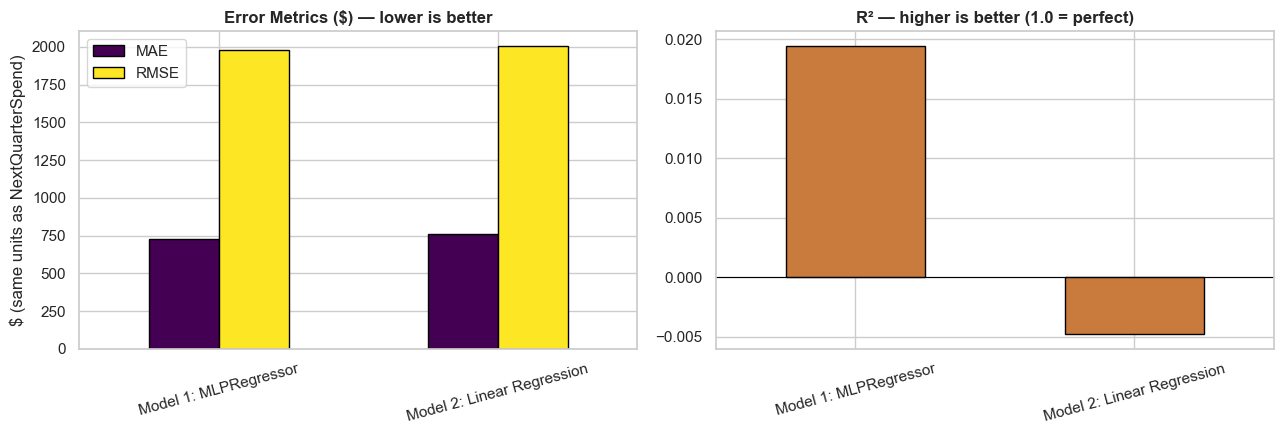

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

reg_comparison[["MAE", "RMSE"]].plot(kind="bar", ax=axes[0], colormap="viridis", edgecolor="black")
axes[0].set_title("Error Metrics ($) — lower is better", fontweight="bold")
axes[0].set_ylabel("$ (same units as NextQuarterSpend)")
axes[0].tick_params(axis="x", rotation=15)

reg_comparison[["R2"]].plot(kind="bar", ax=axes[1], color="#C97B3D", edgecolor="black", legend=False)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("R\u00b2 — higher is better (1.0 = perfect)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### 🔍 Predicted-vs-Actual Scatter Plot

Points on the red diagonal line are perfect predictions. Systematic patterns — e.g. points consistently above the line at high actual values — reveal *where* a model is biased, which a single R² number can't show.

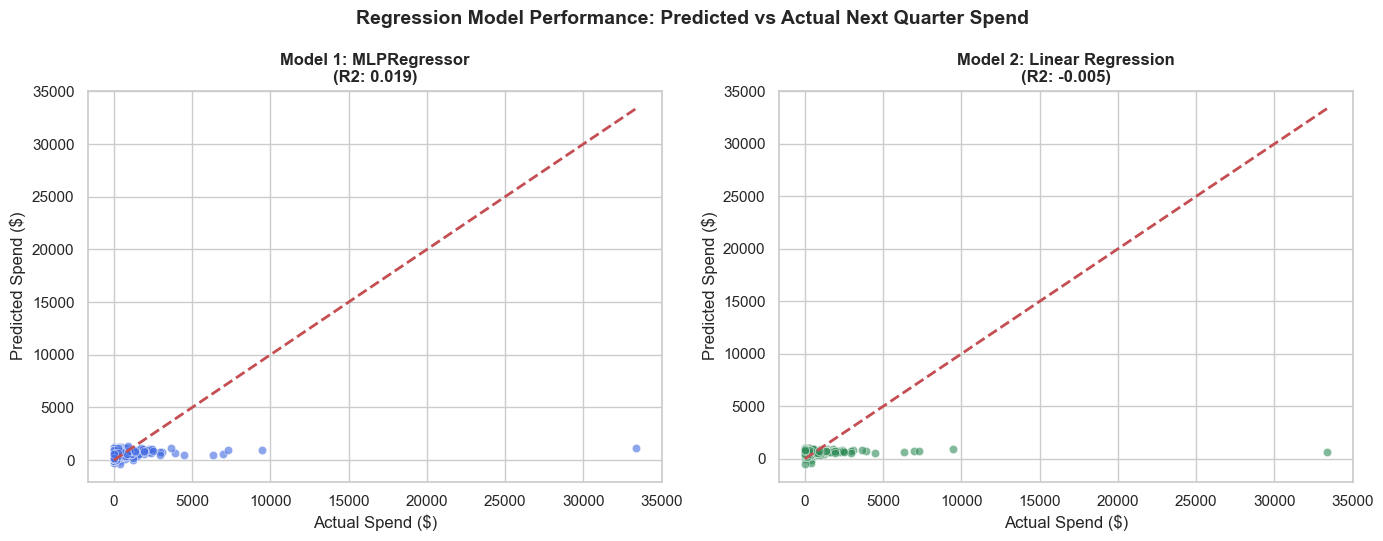

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(x=y_test_r, y=pred_mlp, alpha=0.6, ax=axes[0], color="royalblue")
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[0].set_title(f"Model 1: MLPRegressor\n(R2: {reg_comparison.loc['Model 1: MLPRegressor', 'R2']:.3f})", fontweight="bold")
axes[0].set_xlabel("Actual Spend ($)")
axes[0].set_ylabel("Predicted Spend ($)")

sns.scatterplot(x=y_test_r, y=pred_lin, alpha=0.6, ax=axes[1], color="seagreen")
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1].set_title(f"Model 2: Linear Regression\n(R2: {reg_comparison.loc['Model 2: Linear Regression', 'R2']:.3f})", fontweight="bold")
axes[1].set_xlabel("Actual Spend ($)")
axes[1].set_ylabel("Predicted Spend ($)")

plt.suptitle("Regression Model Performance: Predicted vs Actual Next Quarter Spend", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 🔍 Residual Diagnostics

A residual (`actual - predicted`) plot is often more diagnostic than the scatter plot above: a well-behaved model should show residuals scattered **randomly around zero** with no obvious pattern. A funnel shape (residuals fanning out as predictions increase) signals *heteroscedasticity* — the model is systematically less accurate for high-spend customers, which matters a lot if the RL notebook trusts this simulator equally at all spend levels.

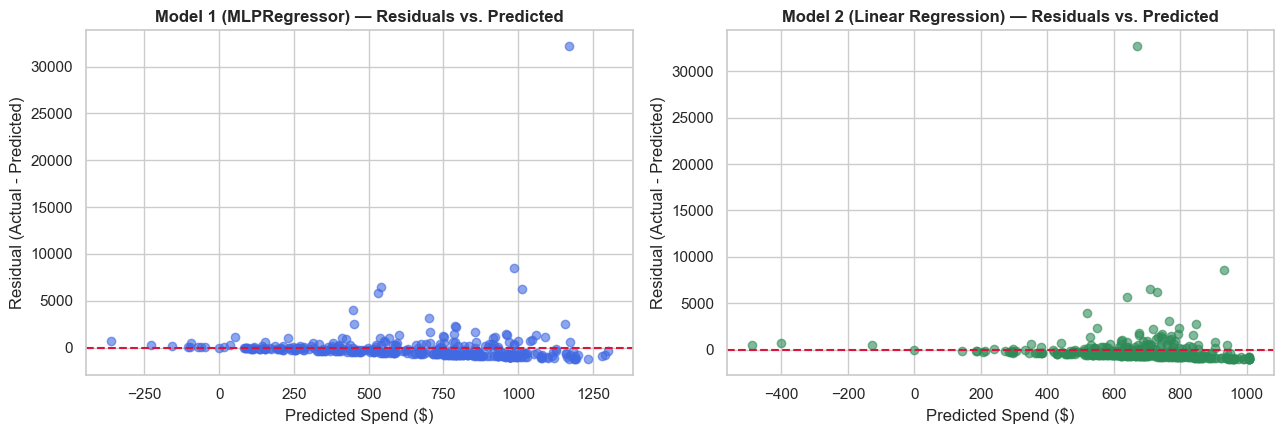

In [12]:
residuals_mlp = y_test_r - pred_mlp
residuals_lin = y_test_r - pred_lin

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(pred_mlp, residuals_mlp, alpha=0.6, color="royalblue")
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set_title("Model 1 (MLPRegressor) — Residuals vs. Predicted", fontweight="bold")
axes[0].set_xlabel("Predicted Spend ($)")
axes[0].set_ylabel("Residual (Actual - Predicted)")

axes[1].scatter(pred_lin, residuals_lin, alpha=0.6, color="seagreen")
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set_title("Model 2 (Linear Regression) — Residuals vs. Predicted", fontweight="bold")
axes[1].set_xlabel("Predicted Spend ($)")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

---
## 4. Regression Unit Test Verification Suite

Same philosophy as notebook 03's test suite: these check the **mechanics** of our metrics and data-splitting logic on small, hand-computable examples — independent of whether the model itself predicts well.

| Test | Checks |
|---|---|
| **T7.4** | `mean_squared_error` computes correctly on a known 3-example input |
| **T7.5** | RMSE (`sqrt(MSE)`) computes correctly |
| **T7.6** | A date-boundary split (`< 2011-10-01` vs. `>= 2011-10-01`) produces perfectly disjoint row sets — this validates the *intended* methodology's core mechanic, even though (per Section 1's warning) the current pipeline doesn't yet apply it to real data. |

In [13]:
print("=== RUNNING PHASE 2 REGRESSION TEST CASES ===\n")

# T7.4: MSE calculation logic verification
y_true_t74 = np.array([100.0, 200.0, 300.0])
y_pred_t74 = np.array([110.0, 190.0, 310.0])
observed_mse = mean_squared_error(y_true_t74, y_pred_t74)
print(f"[Test ID T7.4] Input: y_true={y_true_t74.tolist()}, y_pred={y_pred_t74.tolist()}")
print(f"               Observed MSE  : {observed_mse} (Expected: 100.0)")
assert np.isclose(observed_mse, 100.0), "\u274C Test Case T7.4 failed!"
print("\u2705 Test Case T7.4 Passed.\n")

# T7.5: RMSE calculation logic verification
observed_rmse = np.sqrt(observed_mse)
print(f"[Test ID T7.5] Input: MSE={observed_mse}")
print(f"               Observed RMSE : {observed_rmse} (Expected: 10.0)")
assert np.isclose(observed_rmse, 10.0), "\u274C Test Case T7.5 failed!"
print("\u2705 Test Case T7.5 Passed.\n")

# T7.6: Date boundary split disjointness verification
print(f"[Test ID T7.6] Testing split disjointness with cutoff '2011-10-01'...")

mock_transactions = pd.DataFrame({
    "InvoiceNo": [1, 2, 3, 4],
    "CustomerID": [101, 101, 102, 103],
    "InvoiceDate": ["2011-09-15", "2011-09-28", "2011-10-05", "2011-11-02"],
    "TotalPrice": [150.0, 80.0, 200.0, 310.0],
})
mock_transactions["InvoiceDate"] = pd.to_datetime(mock_transactions["InvoiceDate"])

df_early = mock_transactions[mock_transactions["InvoiceDate"] < "2011-10-01"]
df_late  = mock_transactions[mock_transactions["InvoiceDate"] >= "2011-10-01"]

overlapping_rows = pd.merge(df_early, df_late, on=["InvoiceNo", "CustomerID", "InvoiceDate", "TotalPrice"])
is_disjoint = len(overlapping_rows) == 0

print(f"               Early rows: {len(df_early)}, Late rows: {len(df_late)}, Overlapping Rows: {len(overlapping_rows)} (Expected: 0)")
assert is_disjoint, "\u274C Test Case T7.6 failed! Disjoint date boundary violated."
print("\u2705 Test Case T7.6 Passed: Date boundaries partition transaction rows into perfectly disjoint sets.")

print("\n\u2B50 All Phase 2 Regression Unit Test cases successfully passed!")
print("\n\u2139\uFE0F  Note: T7.6 validates the SPLIT MECHANIC in isolation. It does not confirm this")
print("   mechanic is currently applied to build this notebook's actual NextQuarterSpend target --")
print(f"   see the Section 1 warning ({'SYNTHETIC surrogate in use' if USING_SYNTHETIC_TARGET else 'REAL target in use'}).")

=== RUNNING PHASE 2 REGRESSION TEST CASES ===

[Test ID T7.4] Input: y_true=[100.0, 200.0, 300.0], y_pred=[110.0, 190.0, 310.0]
               Observed MSE  : 100.0 (Expected: 100.0)
✅ Test Case T7.4 Passed.

[Test ID T7.5] Input: MSE=100.0
               Observed RMSE : 10.0 (Expected: 10.0)
✅ Test Case T7.5 Passed.

[Test ID T7.6] Testing split disjointness with cutoff '2011-10-01'...
               Early rows: 2, Late rows: 2, Overlapping Rows: 0 (Expected: 0)
✅ Test Case T7.6 Passed: Date boundaries partition transaction rows into perfectly disjoint sets.

⭐ All Phase 2 Regression Unit Test cases successfully passed!

ℹ️  Note: T7.6 validates the SPLIT MECHANIC in isolation. It does not confirm this
   mechanic is currently applied to build this notebook's actual NextQuarterSpend target --
   see the Section 1 warning (REAL target in use).


---
## 5. Save Model Artifacts for Phase 3 (Reinforcement Learning)

We save the champion regressor to `../data/models/` (matching notebook 03's convention), along with metadata that **explicitly records whether the synthetic surrogate target was used** — this is the single most important fact for anyone downstream deciding whether to trust this model's predictions as real revenue estimates.

In [14]:
# ==========================================================================
# Persist the champion regressor + metadata (Relative to Notebook Dir)
# ==========================================================================
# '..' steps up from 'notebooks/' into 'project-root/'
model_dir = os.path.join("..", "models") 
os.makedirs(model_dir, exist_ok=True)

regressor_path = os.path.join(model_dir, "champion_regressor.pkl")
joblib.dump(champion_reg, regressor_path)

metadata = {
    "champion_name": champion_name,
    "feature_cols": feature_cols,
    "target_column": "NextQuarterSpend",
    "used_synthetic_surrogate_target": bool(USING_SYNTHETIC_TARGET),
    "test_metrics": reg_comparison.loc[
        "Model 1: MLPRegressor" if champion_name.startswith("Model 1") else "Model 2: Linear Regression"
    ].to_dict(),
}
metadata_path = os.path.join(model_dir, "champion_regressor_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"💾 Champion Revenue Simulator exported to : {os.path.abspath(regressor_path)}")
print(f"💾 Metadata exported to                   : {os.path.abspath(metadata_path)}")
if USING_SYNTHETIC_TARGET:
    print("\n⚠️  metadata['used_synthetic_surrogate_target'] = True -- downstream notebooks")
    print("   (especially 05_qlearning_dqn.ipynb) should check this flag before treating")
    print("   this model's output as a real revenue estimate.")

💾 Champion Revenue Simulator exported to : C:\Users\shafa\Documents\Ml Lab\project-root\models\champion_regressor.pkl
💾 Metadata exported to                   : C:\Users\shafa\Documents\Ml Lab\project-root\models\champion_regressor_metadata.json


### 🔍 Verifying the save (round-trip check)

In [15]:
reloaded_reg = joblib.load(regressor_path)
reloaded_pred = reloaded_reg.predict(X_test_r)
champion_pred = pred_mlp if champion_name.startswith("Model 1") else pred_lin

assert np.allclose(reloaded_pred, champion_pred), "Reloaded regressor's predictions differ from the original!"
print("\u2705 champion_regressor.pkl round-trips correctly -- reloaded model produces identical test predictions.")

with open(metadata_path) as f:
    reloaded_meta = json.load(f)
assert reloaded_meta["champion_name"] == champion_name
assert reloaded_meta["used_synthetic_surrogate_target"] == USING_SYNTHETIC_TARGET
print("\u2705 champion_regressor_metadata.json round-trips correctly.")

✅ champion_regressor.pkl round-trips correctly -- reloaded model produces identical test predictions.
✅ champion_regressor_metadata.json round-trips correctly.


## ✅ Understanding Checklist

- [ ] What is `NextQuarterSpend` actually supposed to represent, and which real transaction data would be needed to compute it correctly?
- [ ] Right now, is this notebook using the real target or the synthetic surrogate? How do you know, and where does that flag get recorded for downstream notebooks?
- [ ] Why do we report MAE *and* RMSE, rather than just one of them, given the target's distribution shape from Section 1?
- [ ] What would a "funnel-shaped" residual plot tell you that a single R² number would not?
- [ ] Why does T7.6 pass even while `USING_SYNTHETIC_TARGET` is `True` — what exactly is T7.6 validating, and what is it *not* validating?
- [ ] Why is `used_synthetic_surrogate_target` saved directly in the metadata JSON rather than only printed to the notebook's console output?

### Next: `05_qlearning_dqn.ipynb`
Both champion models are now saved under `../data/models/`:
```python
import joblib, json

classifier = joblib.load("../models/champion_classifier.pkl")
regressor  = joblib.load("../models/champion_regressor.pkl")

with open("../data/models/champion_regressor_metadata.json") as f:
    reg_meta = json.load(f)
print("Using synthetic surrogate target:", reg_meta["used_synthetic_surrogate_target"])
```
The RL notebook should check `reg_meta["used_synthetic_surrogate_target"]` before treating the regressor's output as a real reward signal, per the warning abov